In [1]:
import kagglehub
vasukipatel_face_recognition_dataset_path = kagglehub.dataset_download('vasukipatel/face-recognition-dataset')

100%|██████████| 726M/726M [00:08<00:00, 86.2MB/s]

Extracting files...


In [2]:
vasukipatel_face_recognition_dataset_path

'/root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1'

In [3]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [5]:
data_directory = "/root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1/Original Images/Original Images/"

# Генератор изображений для предварительной обработки
image_gen = ImageDataGenerator()

train_data = image_gen.flow_from_directory(data_directory, target_size=(224, 224), batch_size=32)

class_names = list(train_data.class_indices.keys())

Found 2562 images belonging to 31 classes.


In [7]:
# Создание пустой последовательной модели, куда будем добавлять слои по порядку
cnn_model = Sequential()

# Conv2D - свёрточный слой. Каждый из этих слоев выполняет операцию свёртки, у каждого слоя свёртки:
# первый аргумент - количество фильтров
# kernel_size — размер фильтра
# activation='relu' — функция активации ReLU для нелинейности

cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(224, 224, 3)))

# MaxPooling2D - пуллинговый слой, который уменьшает размерность изображений, сохраняя основные характеристики
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))

# BatchNormalization - нормализация на каждом слое для ускорения обучения и улучшения стабильности
cnn_model.add(BatchNormalization())

cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(BatchNormalization())

cnn_model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(BatchNormalization())

cnn_model.add(Conv2D(96, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(BatchNormalization())

cnn_model.add(Conv2D(32, kernel_size=(3, 3), activation='relu'))
cnn_model.add(MaxPooling2D(pool_size=(2, 2)))
cnn_model.add(BatchNormalization())

# Dropout(0.2) - слой, который случайным образом отключает 20% нейронов в процессе обучения для предотвращения переобучения
cnn_model.add(Dropout(0.2))

# Flatten() - преобразует многомерный тензор в одномерный, чтобы его можно было передать в полносвязный слой
cnn_model.add(Flatten())

# Dense(128) - полносвязный слой с 128 нейронами и функцией активации ReLU
cnn_model.add(Dense(128, activation='relu'))

# Выходной слой, где количество нейронов равно количеству классов.
# Функция активации softmax используется для многоклассовой классификации, преобразуя вывод в вероятности для каждого класса
cnn_model.add(Dense(len(class_names), activation='softmax'))

/usr/local/lib/python3.10/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
cnn_model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

In [9]:
cnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 111, 111, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 54, 54, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 26, 26, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 96)          │          55,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 12, 12, 96)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 12, 12, 96)          │             384 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 10, 10, 32)          │          27,680 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 5, 5, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 5, 5, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 800)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         102,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 31)                  │           3,9

 Total params: 247,071 (965.12 KB)

 Trainable params: 246,495 (962.87 KB)

 Non-trainable params: 576 (2.25 KB)

In [10]:
training_history = cnn_model.fit(train_data, epochs=30, batch_size=32)

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


81/81 ━━━━━━━━━━━━━━━━━━━━ 351s 4s/step - accuracy: 0.0720 - loss: 3.6766
Epoch 2/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.2205 - loss: 2.7760
Epoch 3/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 339s 4s/step - accuracy: 0.3166 - loss: 2.3423
Epoch 4/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 331s 4s/step - accuracy: 0.4184 - loss: 1.9411
Epoch 5/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 390s 4s/step - accuracy: 0.5484 - loss: 1.5092
Epoch 6/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 370s 4s/step - accuracy: 0.6528 - loss: 1.1856
Epoch 7/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 387s 4s/step - accuracy: 0.7072 - loss: 1.0000
Epoch 8/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 380s 4s/step - accuracy: 0.7138 - loss: 0.9247
Epoch 9/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.8493 - loss: 0.5773
Epoch 10/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 381s 4s/step - accuracy: 0.8601 - loss: 0.4822
Epoch 11/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 329s 4s/step - accuracy: 0.9011 - loss: 0.3732
Epoch 12/30
81/81 ━━━━━━━━━━━━━━━━━━━━ 382s 4s/step - accuracy: 0.9389 - l

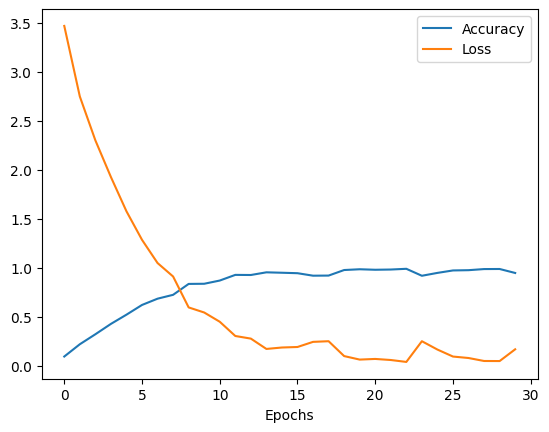

In [11]:
plt.plot(training_history.history['accuracy'])
plt.plot(training_history.history['loss'])
plt.xlabel('Epochs')
plt.legend(['Accuracy', 'Loss'])
plt.show()

In [12]:
cnn_model.save('face_recognition_model.h5')

In [13]:
def predict_person(image_path, threshold=0.7):
    # Загрузка и преобразование изображения
    img = image.load_img(image_path, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    # Прогнозирование
    predictions = cnn_model.predict(img_array, batch_size=32)

    # Получаем максимальную вероятность и имя предсказанного класса
    max_prob = np.max(predictions)
    predicted_class = class_names[np.argmax(predictions)]

    # Если вероятность предсказания больше порогового значения, выводим имя
    if max_prob > threshold:
        print(f"Я думаю, это: {predicted_class} (Уверенность: {max_prob:.2f})")
    else:
        print("Я не знаю этого человека.")

In [14]:
predict_person("/root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1/Original Images/Original Images/Anushka Sharma/Anushka Sharma_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 311ms/step
Я думаю, это: Anushka Sharma (Уверенность: 0.96)


In [15]:
predict_person("/root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1/Original Images/Original Images/Camila Cabello/Camila Cabello_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Я думаю, это: Camila Cabello (Уверенность: 1.00)


In [16]:
predict_person("/root/.cache/kagglehub/datasets/vasukipatel/face-recognition-dataset/versions/1/Original Images/Original Images/Brad Pitt/Brad Pitt_1.jpg")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Я думаю, это: Brad Pitt (Уверенность: 0.95)
